In [ ]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
 
cal_housing = fetch_california_housing()
df = pd.DataFrame(cal_housing.data, columns=cal_housing.feature_names)

df['target'] = cal_housing.target

df_sampled = df.sample(n=4000)


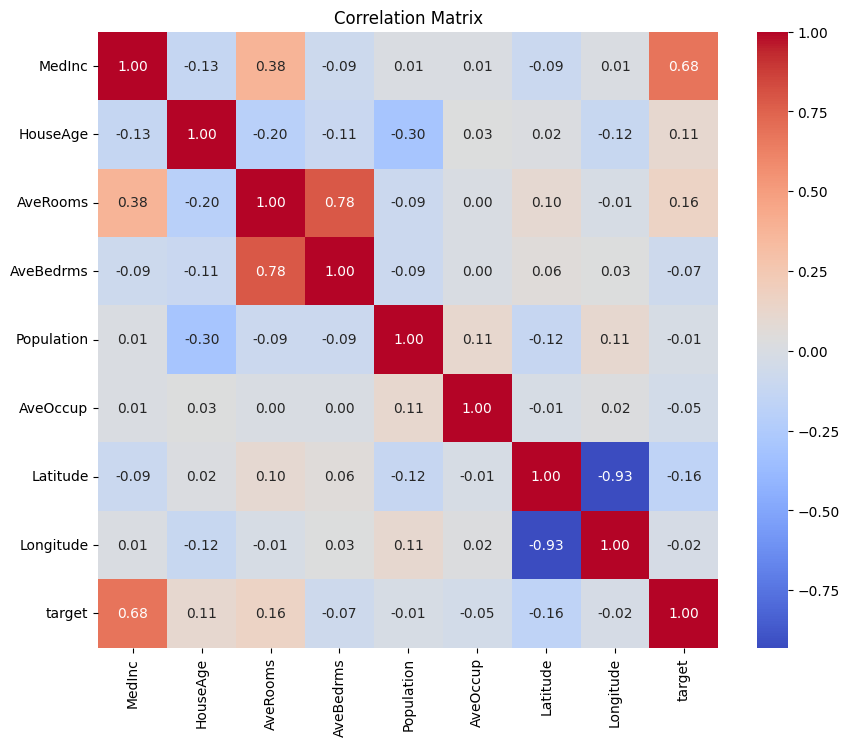

In [3]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_sampled.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

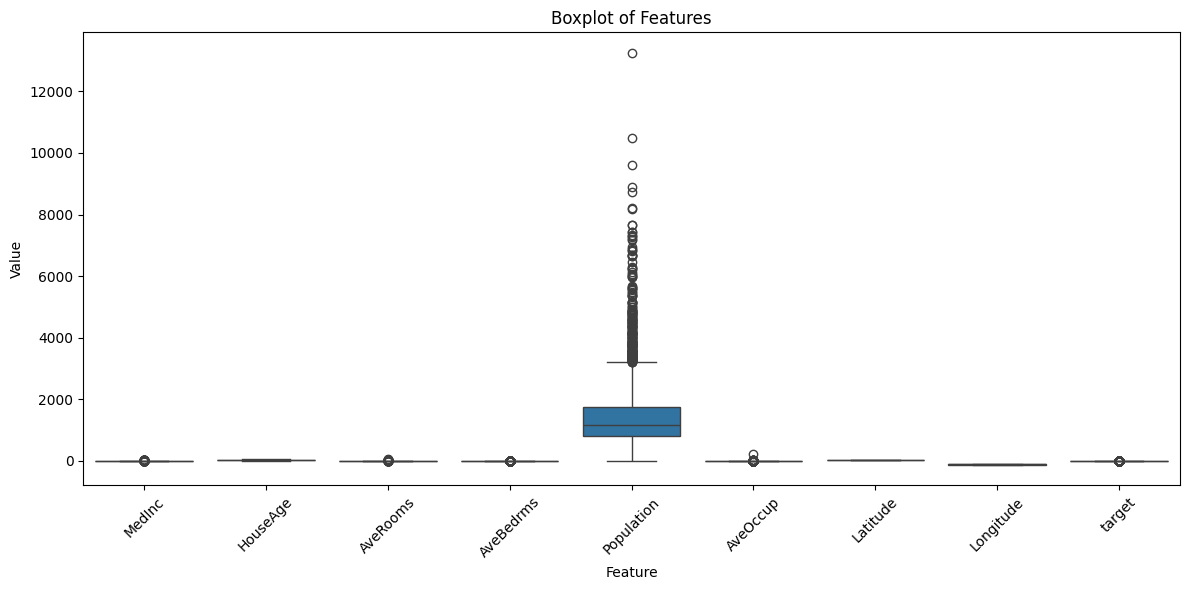

In [8]:
df_melted = df_sampled.melt(var_name="Feature", value_name="Value")
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_melted, x="Feature", y="Value")
plt.xticks(rotation=45)
plt.title("Boxplot of Features")
plt.tight_layout()
plt.show()

In [4]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, make_scorer
import numpy as np

cal = fetch_california_housing()
X = pd.DataFrame(cal.data, columns=cal.feature_names)
y = cal.target

model = LinearRegression()

cv = KFold(n_splits=10, shuffle=True, random_state=42)

mse_scores = cross_val_score(model, X, y, cv=cv, scoring=make_scorer(mean_squared_error))

print("10-Fold Cross-Validation (MSE):")
print("fold:", mse_scores)
print("avg MSE:", np.mean(mse_scores))

10-Fold Cross-Validation (MSE):
fold: [0.55900192 0.5531233  0.48116128 0.57420367 0.48897584 0.52838818
 0.55117824 0.47483961 0.56436922 0.55002537]
avg MSE: 0.5325266619260601


In [5]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split


cal = fetch_california_housing()
X = pd.DataFrame(cal.data, columns=cal.feature_names)
y = cal.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"📈 RMSE: {rmse:.3f}")
print(f"📊 R² score: {r2:.3f}")

📈 RMSE: 0.746
📊 R² score: 0.576


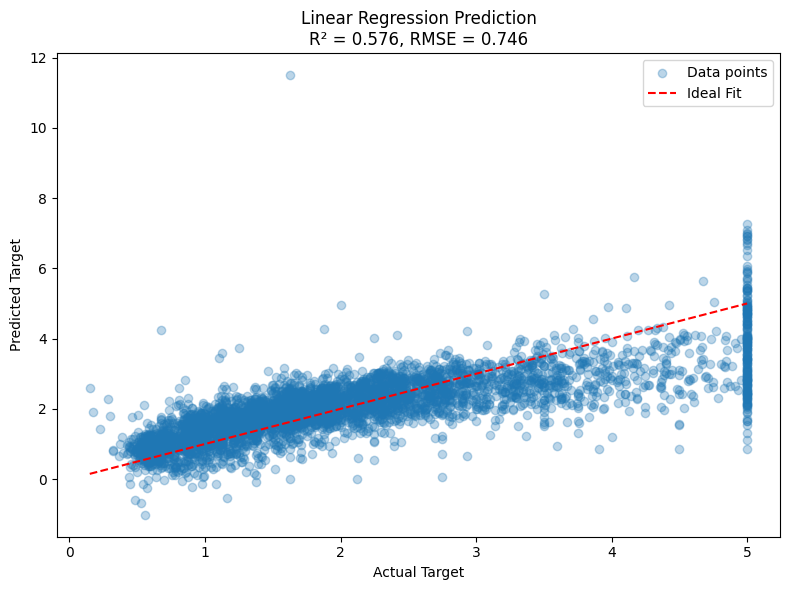

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

cal = fetch_california_housing()
X = pd.DataFrame(cal.data, columns=cal.feature_names)
y = cal.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, label='Data points')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Ideal Fit')
plt.xlabel("Actual Target")
plt.ylabel("Predicted Target")
plt.title(f"Linear Regression Prediction\nR² = {r2:.3f}, RMSE = {rmse:.3f}")
plt.legend()
plt.tight_layout()
plt.show()